# Section 4 Optional: Solving a One-Asset HANK model via SSJ Method

**Issues/Questions? Contact me via maragoneses@g.harvard.edu**

In this notebook we show how to
1. [Adapt general HA blocks to specific models](#1-hetblock)
2. [Solve for a steady state with multiple calibration targets](#2-calibration)
3. [Compute linearized impulse responses: unwrap convenience function](#3-linear)
4. [Compute nonlinear impulse responses: quasi-Newton performs well even for large nonlinearities](#4-nonlinear)
5. [Check local determinacy](#5-determinacy)

The model is a HA version of the textbook New Keynesian model. Technology is linear in labor, prices are sticky á la Rotemberg, and monetary policy follows a Taylor rule. For a detailed description of the model, please see the paper. 

The asset demand and labor supply functions $\{\mathcal{A}, \mathcal{L}\}$ follow from the household block with Bellman equation

$$
\begin{align} \tag{HH}
V_t(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \sum_{e'}V_{t+1}(e', a) \mathcal{P}(e,e') \right\}
\\
c + a &= (1 + r_t)a_{-} + w_t e n - \tau_t \bar{\tau}(e) + d_t \bar{d}(e)
\\
a &\geq 0
\end{align}
$$

where $\bar\tau(e)$ and $\bar d(e)$ are skill-specific incidence rules for taxes and dividends. $\bar{d}(e)$ is the share of e-type households in aggregate dividends. To see where this equation comes from, let's derive this from first principles: assume the household starts with a share $\lambda_{t-1}(e)$ of stock holdings, priced at $v_t$, receiving a dividend stream, and updates hist portfolio choice.

$$ c + a + v_t \lambda_t(e) = (1 + r_t)a_{-} + w_t e n - \tau_t \bar{\tau}(e) + (d_t + v_t)\lambda_{t-1}(e) $$ 

Assume agents are not allowed to trade the financial asset they are endowed with so that $\lambda_t(e) = d(e)$ in every period. Then, rebalancing is of no consequence, and thus, 

$$ c + a = (1 + r_t)a_{-} + w_t e n - \tau_t \bar{\tau}(e) + d_t d(e) $$ 

This will be enriched once we allow agents to trade both assets. 

From the household block, one can solve for equilibrium policies $c_{t}\left(e,a_{-}\right),n_{t}\left(e,a_{-}\right)\text{and }a_{t}\left(e,a_{-}\right)$ as a function of the paths of $\left\{ r_{s},w_{s},\tau_{s},d_{s}\right\} _{s\geq t}$ yielding aggregate consumption, employment, and assets  

\begin{aligned}
\mathcal{N}_{t}\left(\left\{ r_{s},w_{s},\tau_{s},d_{s}\right\} _{s\geq0}\right) & \equiv\int en_{t}(a_{-},e)dD_{t}\left(e,a_{-}\right)\\
\mathcal{A}_{t}\left(\left\{ r_{s},w_{s},\tau_{s},d_{s}\right\} _{s\geq0}\right) & \equiv\int adD_{t}\left(e,a_{-}\right)\\\mathcal{C}_{t}\left(\left\{ r_{s},w_{s},\tau_{s},d_{s}\right\} _{s\geq0}\right) & \equiv\int c_{t}(a_{-},e)dD_{t}\left(e,a_{-}\right)
\end{aligned}

where the first replaces the aggregate labor supply equation and the two last equations aggregate over the individual Eulers and budget constraints and replace the aggregate Euler equation. As we did in the Krusell Smith economy, only one of them is needed. 

The firm block is described by production and profits.

$$ Y_{t}=Y_{t}\left(Z_{t},L_{t}\right)=Z_{t} L_{t}\quad\text{Good Supply}$$

$$ d_{t} = d_{t}(Y_{t},w_{t},L_{t},\pi_{t})= Y_{t} - w_{t} L_{t} -I_t \quad I_t := \frac{\mu}{\mu-1} \frac{1}{2 \kappa} \log \left(1+\pi_{t}\right)^{2}Y_{t}$$

where the problem of the firm is to pick production output and inputs, as well as prices subject to own price adjustment costs.

\begin{aligned}J_{t}\left(p_{jt-1}\right)=max_{y_{jt},p_{jt},n_{jt}}\ \frac{p_{jt}}{p_{t}}y_{jt}-w_{t}n_{jt}-\frac{\mu}{\mu-1}\frac{1}{2\kappa}\left[\log\left(1+\pi_{jt}\right)\right]^{2}Y_{t}+\frac{J_{t+1}\left(p_{jt}\right)}{1+r_{t+1}}\quad\text{ s.t. } \quad Z_{t}n_{jt} = y_{jt}  = \left(\frac{p_{jt}}{p_{t}}\right)^{-\frac{\mu}{\mu-1}}Y_{t}\end{aligned}

Technically, dynamic pricing could also forms part of the firm block since it's an investment decision. Here, we will define a separate aggregate (using symmetry with unit mass firms $p_{jt}=p_{t}$ ) pricing block described by the NKPC clearing. 

$$\log \left(1+\pi_{t}\right) = \kappa\left(\frac{w_{t}}{Z_{t}}-\frac{1}{\mu}\right)+\frac{1}{1+r_{t+1}} \frac{Y_{t+1}}{Y_{t}} \log \left(1+\pi_{t+1}\right)\quad\text{Price Setting: NKPC}$$

The market clearing block 

$$H_L(r_{s},w_{s},\tau_{s},d_{s},L_{s})= \mathcal{N}_{t}\left(\left\{r_{s}, w_{s}, \tau_{s}, d_{s}\right\}\right)-L_{t} = 0\quad\text{Labor Market S = D}$$

$$H_A(r_{s},w_{s},\tau_{s},d_{s},B)=\mathcal{A}_{t}\left(\left\{r_{s}, w_{s}, \tau_{s}, d_{s}\right\}\right)-B = 0 \quad\text{Asset Market S = D}$$

Notice the later equation is the same as in Krusell Smith, and the forming was omitted there since labor supply was inelastically 1.  

The government block constains fiscal and monetary policy 

$$ \begin{array}{c}
\tau_{t}=\tau_{t}(r_{t},B)=r_{t} B \\
i_{t} = i_{t}(\pi_{t},r_{t}^{*})=\phi \pi_{t} + r_{t}^{*}
\end{array}
$$

Notice that the government follows a fiscal rule with constant debt and no spending. Notice that in general, debt (negative assets) are a form of negative investment that allows the government (much like firms) to "consume" more today (have higher spending) above and beyond what they can afford with net tax revenues $\tau_{t}$ net of payments on exitsting debt. Leaving debt constant at $B$ to be calibrated

$$  G_{t} - B_{t} = \tau_{t} - (1+r_{t}) B_{t-1} = \tau_{t} - r_{t}B = 0 $$

This relates the policy parameter to endogenous variables $\tau_{t}(r_{t},B)$. Naturally, one can think of the downward slopping "demand" $ B = \tau/r_t$ for assets in the econonomy as coming from government bonds issued by the government. Note this is unlike the KS economy where household's assets were going towards financing firm's capital investment. Note that in economies with a no-borrowing constraint where there's no household counterparty for potential savers, governments (or firms) are a key source of liquidity in the model, moving the economy away from zero-net-supply assets. 

Finally, we need a link between real and monetary objects. Defining real interest rates is the Fisher equation, which represents a no-arbitrage condition between nominal and real bonds.

$$  1 + r_t = \frac{1+i_{t-1}}{1+\pi_t} $$

To derive this, note that for an unconstrained "saver" with an arbitrary type omited here for clarity, who price the assets, we have the following two Euler equations,

$$p_t (c +  a) =  (1 + r_t)(p_t/p_{t-1}) p_{t-1}a_{-} + p_t (w_t e n - \tau_t \bar{\tau}(e) + d_t \bar{d}(e)) $$
$$p_t (c +  a) =  (1+i_{t-1}) p_{t-1}a_{-} + p_t (w_t e n - \tau_t \bar{\tau}(e) + d_t \bar{d}(e)) $$
$$ u'(c_{it}) = \beta (1+r_{t+1})E_{e'|e}(u'(c_{t+1i})) $$
$$ u'(c_{it}) = \beta (1+i_{t})(p_{t}/p_{t+1})E_{e'|e}(u'(c_{t+1i})) \iff (1+r_{t+1}) = (1+i_{t})/(1+\pi_{t+1})$$

Note this enphasizes the point that while the price for tomorrow's savings $r_{t+1}$ is endogenous to expected (or here known) future inflation $\pi_{t+1}$ (since inflation erodes savings), bonds are paid the interest rate currently set by the government (which will respond to "current" inflation). Combining the policy rule and the no-arbitrage condition we get that the real interest rate on tomorrow's savings is depressed by expected inflation, but increases in current inflation, since the gov is trying to cool down the economy by ranking up nominal rates. 

$$r_{t+1} = r_{t+1}(\pi_{t},\pi_{t+1},r_{t}^{*}) = (1 + ( \phi \pi_{t} + r_{t}^{*}) )/(1+\pi_{t+1}) - 1 $$

Note that aggregating the budget constraint shows Walras Law in action delivering goods markets clearing 

$$\mathcal{C}_{t} + \mathcal{A}_{t} = (1 + r_t)\mathcal{A}_{t-1} + w_t \mathcal{N}_{t} - \tau_t  + d_t $$

Since the supply of bonds from the goverment, who demand the savings households provide (households save only in government bonds) is fixed in equilibrium, so is $\mathcal{A}_{t} = B$ even outside the steady state. Since taxes must perfectly track debt repayments and profits are value added minus costs

$$\mathcal{C}_{t} + B = (1 + r_t)B + w_t \mathcal{N}_{t} - \tau_t  + d_t $$

$$\mathcal{C}_{t} + B = (1 + r_t)B + w_t \mathcal{N}_{t} - r_t B  + (Y_t - w L_t - I_t)$$

$$\mathcal{C}_{t} = Y_t - I_t $$


As a reminder, the model can be summarized in sequence form as

$$
\textbf{H}_t(\textbf{Y}, Z) \equiv 
\begin{pmatrix}
Y_t - Z_t L_t
\\
Y_t \left[1 - \frac{\mu}{\mu-1}\frac{1}{2\kappa} \log(1 + \pi_t)^2\right] - w_t L_t - d_t
\\
r_t B - \tau_t
\\
r^*_t + \phi \pi_t - i_t
\\
1 + r_t - \frac{1+i_{t-1}}{1+\pi_t}
\\
\kappa \left(\frac{w_t}{Z_t} - \frac{1}{\mu} \right)  + \frac{1}{1+r_{t+1}} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}) - \log(1+\pi_t)
\\
\mathcal{A}_t(\{r_s, w_s, \tau_s, d_s\})  - B
\\
\mathcal{N}_t(\{r_s, w_s, \tau_s, d_s\}) - L_t
\end{pmatrix}
= \begin{pmatrix} 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0\end{pmatrix},
\qquad t = 0, 1, \dots
$$

where the endogenous variables are $\textbf{Y} = (Y, L, r, w, d, \pi, \tau, i)$ and the exogenous variables are $\textbf{Z}=(r^*, Z)$. 

We can reduce the model to it's essential ingredients by combining equilibrium conditions. 

$$H_L = \mathcal{N}_{t}\left(\left\{r_{s}(\pi_{s-1},\pi_{s},r_{s-1}^{*}), w_{s}, \tau_{s}(r_{s}(\pi_{s-1},\pi_{s},r_{s-1}^{*})), d_{t}(Y_{s},w_{s},(Y_s/Z_s),\pi_{t})\right\}\right)-(Y_t/Z_t) = 0\quad$$

$$H_A=\mathcal{A}_{t}\left(\pi_s,Y_s,w_s;r_s^{*},Z_t)\right)-B = 0 \quad$$

$$H_P = \kappa \left(\frac{w_t}{Z_t} - \frac{1}{\mu} \right)  + \frac{1}{1+r_{t+1}(\pi_{t+1},\pi_{t},r_{t}^{*})} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}) - \log(1+\pi_t) \quad$$


We can then think of the model as a directed acyclical graph (DAG) with **3 endogenous inputs**

![Directed Acyclical Graph](figures/hank1_dag.png) 

and write it as an implicit function

NOTE: There is a typo in the code of the original notebook, should be $r^{*}$

$$
H(\pi, Y, w; \epsilon, Z) = 0.
$$

In the steady state with zero inflation and $Y = L = 1,r=1\%$ implies that following standard results:

$$ Z = Y/L = 1\implies w= \frac{Z}{\mu} = 1/{\mu}$$

$$ d = \left(1 - \frac{1}{\mu}\right)Y = 1 $$

$$ r = i = 0.01$$ 

all we need to solve for is for ${\beta},\varphi$ that deliver those aggregates, and we'll only need two conditions to hold, asset market clearing (as in KS), and labor market clearing (which in RBC could be done analytically).

$$H_A=\mathcal{A}_{t}\left(\varphi,\beta\right)-B = 0 \quad$$

where the steady state problem features a constant V function and a stationary distribution D since all aggregates are time invariant

$$
\begin{align} \tag{HH}
V(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \sum_{e'}V(e', a) \mathcal{P}(e,e') \right\}
\\
c + a &= (1 + r)a_{-} + w e n - \tau \bar{\tau}(e) + d \bar{d}(e)
\\
c + a &= (1 + 0.01)a_{-} + (1/\mu)e n - (0.01B) \bar{\tau}(e) + (1-1/\mu) \bar{d}(e)
\\
a &\geq 0
\end{align}
$$

In the steady state, there's zero investment, and thus, aggregate consumption

$$ C = Y = 1 $$

individual consumption and savings are determined by the micro Euler equations for unconstrained household

$$ c = (\beta (1+r))^{-1/\sigma}) ((\Pi c')^{\sigma})^{-1/\sigma} $$

and by the static budget constraint for the rest

$$c = (1 + r)a_{-} + w e n - \tau \bar{\tau}(e) + d \bar{d}(e)$$


$$H_L = \mathcal{N}\left(\varphi,\beta\right)-1 = 0\quad$$

Note the model is non-linear, and as such, we cannot perfectly solve each target with one variable. 

QUESTION: why the need to have 3 variables? Can solve for the wage rate implied by the NKPC

$$ w_t  = w_t(Y_s,\pi_s;Z_s,r_{s}^{*}) = {Z_t} \left[ \frac{1}{\mu} +  (1/\kappa)(\log(1+\pi_t) - \frac{1}{1+r_{t+1}(\pi_{t+1},\pi_{t},r_{t}^{*})} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}))\right] \quad$$

So that the economy can be solved as a function of only two endogenous variables $\pi,Y$?

## 0 Import packages
The first two are standard python packages, the rest contain code we wrote for this project.

In [1]:
# Python packages
import numpy as np
import matplotlib.pyplot as plt
from numba import vectorize, njit

# Already studied in Krusell-Smith
import utils
from het_block import het
import simple_block as sim
from simple_block import simple
import jacobian as jac
import nonlinear

# New packages for HANK
import hank
import determinacy as det

<a id="1-hetblock"></a>

## 1 Adapting HA blocks with hetinput attachments

As we have seen in the Krusell-Smith notebook, the main task in setting up HA blocks is to write a backward iteration function that represents the Bellman equation. This has to be a single step of an iterative solution method such as value function iteration. For the standard income fluctuation problem with endogenous labor supply we're dealing with here, the endogenous gridpoint method of [Carroll (2006)](https://www.sciencedirect.com/science/article/pii/S0165176505003368) is the best practice.

Solving the endogenous-labor problem via EGM is standard but somewhat tedious and so the details are left to ``hank.py``. Instead we will focus on a new feature that makes it much easier to adapt HetBlocks to different macro enviroments.

The backward iteration function `hank.household` corresponds to the general problem:

$$
\begin{align} \tag{HH-general}
V_t(e, a_{-}) = \max_{c, n, a} &\left\{\frac{c^{1-\sigma}}{1-\sigma} - \varphi \frac{n^{1+\nu}}{1+\nu} + \beta \sum_{e'}V_{t+1}(e', a) \mathcal{P}(e,e') \right\}
\\
c + a &= (1 + r_t)a_{-} + w_t e n + T_t(e)
\\
a &\geq 0
\end{align}
$$

That is, households take as given the sequence of interest rates $r_t$, wages $w_t$ and skill-specific transfers $T_t(e).$ In the context of this particular HANK model, transfers equal dividends minus taxes. But it's easy to imagine many other cases. Rather than writing a specific backwatd iteration function for each of them, we can just supply a function that specifies how the $\{r_t, w_t, T_t(e)\}$ are determined in this particular case. We refer such functions as **hetinput**. 


Since $r_t$ and $w_t$ correspond directly to aggregate variables of the model, we only have to specify transfers:

In [2]:
def transfers(pi_e, Div, Tax, e_grid, div_rule, tax_rule):    
    div = Div / np.sum(pi_e * div_rule) * div_rule
    tax = Tax / np.sum(pi_e * tax_rule) * tax_rule
    T = div - tax
    return T

Let's attach this hetinput function to the generic household HetBlock using (the aptly-named) ``HetBlock.attach_hetinput`` method.

In [3]:
household = hank.household.attach_hetinput(transfers)

Each HetBlock can be associated with at most one hetinput. Once it is attached, every call to the HetBlock will be routed through the hetinput function first.

### EGM Value Function Iteration with Endog Labor Supply and Transfers

(Feel free to skip this section if you want to go straight to the results). 

Let's solve the household problem with endogenous labor supply and transfers and compare it to the problem we saw in HA-RBC. There, we defined a household VFI function `Va, a, c = household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis)` taking as given a guess for the derivative of the expected VF, the points in the grid, anyendogenous aggregates affecting household cash on hand/income (r,w) since over the grid cash on hand was

`coh = w * e_grid[:, np.newaxis] + (1 + r) * a_grid[np.newaxis, :]`

and other parameters (Pi_p), and the grid for a_ and e. The procedure household @ het then produced optimal policies (consumption and investment) as well as an updated guess for the value function's derivative at this solution. 

`
@het(exogenous='Pi', policy='a', backward='Va')

def household(Va_p, Pi_p, a_grid, e_grid, r, w, beta, eis):
...

    # Marginal utility of consumption today taking an expected value S*S @ S*A -> S*A (e,a)
    uc_nextgrid = (beta * Pi_p) @ Va_p
    
    # Implied consumption. Note consumption is of dymension S*A
    c_nextgrid = uc_nextgrid ** (-eis)
    
    # Cash on Hand(e,a). Need to create a general xq = we + (1+r)a on the grid 
    coh = w * e_grid[:, np.newaxis] + (1 + r) * a_grid[np.newaxis, :] 
    
    # Since x = c + b' is off the grid (because of c, while b' and b use the same grid)
    # Here we are saying general y = a_grid = b' is to x =  c + b' = c + a_grid, what yq is to xq = coh 
        # yq = utils.interpolate_y(x, xq, y)
    a = utils.interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    
    # armed with a'(e,a_), we need to make sure that savings is constrained at the borrowing constrained
    utils.setmin(a, a_grid[0])
    
    # Given coh(e,a_), and policy a'(e,a_) we can back out consumption residually
    c = coh - a
    
    # Return a new guess for Va. Notice that we are doing this in the steady state where r = r'
    Va = (1 + r) * c ** (-1 / eis)
    
    return Va, a, c
`
 
A nice reference here is [https://www.sas.upenn.edu/~jesusfv/Endogenous_Grid.pdf]. 
 
With our new ingredients, we need to add another parameter, in this case, an array like the grid, `T` with the new elements that add to cash on hand: taxes and dividends. In addition, we need to add new parameters affecting the labor supply decision. 

We want to know the optimal n in every period taking as given the dynamic investment choice ($a'$). 

This is a constrained optimization problem solved in `solve_uc` with a relaxed constraint (given $a$). 

$max_{c, n} c^{(1-\sigma)} + \varphi*n^{(1+\nu)} s.t. c = w*n + T (= z)$

`solve_uc` takes an initial guess for $u_c$ and gets the net expenditure (and it's derivative) that corresponds to it. 

`ne, ne_p = netexp(log_uc, w, T, eis, frisch, vphi)`

Consumption and employment depend on the marginal utility of consumption. To solve the individual decision problem, note that, given $u'(c)=c^{-\sigma}$ 
$$ c = u_c^{-1/\sigma}$$

Further, note that invidual labor supply
$$ w_s u_c = v'(n) = \varphi n^{\nu} \iff n = ((w_s u_c)/\varphi)^{1/\nu}$$

We will first produce a function that returns these two optimal policies given a level of marginal utility `u_c`. Note such level of marginal utility is produced given our guess of the partial derivative of the value function

`uc = (beta * Pi_p) @ Va_p`

`c,n = cn(uc, ws[:, np.newaxis], eis, frisch, vphi)`
 
`c,n` can be used in conjunction with $T$ and $w_s$ (with appropriate replications to make sure arrays have the same size: `ws[:, np.newaxis]`) to know what *net expenditure* rearranging the budget constraint, i.e. the terms that do not depend on the savings choice we are picking dynamically.

$$ ne  = c(e,a_{-}) - z(e,a_{-}) = c(e,a_{-}) - w_s(e) n(e,a_{-}) - T(e,a_{-}) = - a + (1+r)a_{-} $$

Given the above, 

$$ ne = u_c(e,a_{-})^{-1/\sigma} - w_s(e) u_c(e,a_{-})^{-1/\nu} - T(e,a_{-}) $$

Or log-linearizing 

$$ e^{\log(ne)} = e^{{-1/\sigma}\log{u_c(e,a_{-})}} - w_s(e) e^{-1/\nu\log{u_c(e,a_{-})}} - T(e,a_{-}) $$

and then takes them as given to construct the derivative of total expenditures wrt it

$$ d(ne) = {-1/\sigma}c d\log(u_c) - w_s(e)n {1/\nu} d\log(u_c) $$

This is what is produced in the function

`ne, ne_p = netexp(log_uc, w, T, eis, frisch, vphi)`

which checks whether for a given $u_c$ level, the implied optimal consumption and employment choices satisfy the budget constraint of the household (i.e. whether ne = 0). If it doesn't, we need a new guess for `u_c`. Using Newton's method to find the $u_c$ that makes $ne$ cross 0 via the tangent of ne so that

$$ 0 = ne^{1} = ne^{0} + d(ne^{0})/d\log(u_c^{0})\left(\log(u_c^{1}) - \log(u_c^{0})\right) $$


$$\log(u_c^{1}) =  \log(u_c^{0}) - \frac{ne^{0}}{d(ne^{0})/d\log(u_c^{0})}   $$

Iterating on  $\log(u_c)$ a few times, we find it's optimal level

`uc = solve_uc(w, T, eis, frisch, vphi, uc_seed)`

with optimal choices then produced by `c,n = cn(uc, w, eis, frisch, vphi)`.

 





In [4]:
# @njit = Numba decorator that makes loops (easier to write) be as fast as vectorized code (harder to write)
@njit 
def cn(uc, w, eis, frisch, vphi):
    """Return optimal c, n as function of u'(c) given parameters"""
    return uc ** (-eis), (w * uc / vphi) ** frisch

def netexp(log_uc, w, T, eis, frisch, vphi):
    """Return net expenditure as a function of log uc and its derivative."""
    c, n = cn(np.exp(log_uc), w, eis, frisch, vphi)
    ne = c - w * n - T

    # c and n have elasticities of -eis and frisch wrt log u'(c)
    c_loguc = -eis * c
    n_loguc = frisch * n
    netexp_loguc = c_loguc - w * n_loguc

    return ne, netexp_loguc

# This function simply evaluates solve_uc(w, T, eis, frisch, vphi, uc_seed) and returns c , n = cn(uc, w, eis, frisch, vphi)
def solve_cn(w, T, eis, frisch, vphi, uc_seed):
    uc = solve_uc(w, T, eis, frisch, vphi, uc_seed)
    return cn(uc, w, eis, frisch, vphi)

# @vectorize = Numba decorator turning stuff into C for speed
@vectorize
def solve_uc(w, T, eis, frisch, vphi, uc_seed):
    """Solve for optimal uc given in log uc space.

    max_{c, n} c**(1-1/eis) + vphi*n**(1+1/frisch) s.t. c = w*n + T
    """
    log_uc = np.log(uc_seed)
    for i in range(30):
        ne, ne_p = netexp(log_uc, w, T, eis, frisch, vphi)
        if abs(ne) < 1E-11:
            break
        else:
            log_uc -= ne / ne_p
    else:
        raise ValueError("Cannot solve constrained household's problem: No convergence after 30 iterations!")

    return np.exp(log_uc)



In [5]:
household = hank.household.attach_hetinput(transfers)

The code to do the VFI step for the household problem is then standard. 

Importantly, here's a moment where we see that $T$ does not directly affect optimal choices among those unconstrained. 

Armed with the optimal choices *off the grid*, we need to make sure the budget constraint holds when these choices are interpolated *on the grid*. Rearranging the budget constraint like we did before with inelastic labor supply expanding the RHS won't do because our previous notion of cash on hand now depends on $n(e,a')\ne1$

$$ \text{Exog LS}\quad LHS(e,a') = c(e,a') + a' = z(e,a_{-}) = (1+r)a_{-} + w_s n = RHS(e,a_{-})\iff $$

where we simply had to find the $c(e,a_{-})$ - on the $a_{-}$ grid that was to $z(e,a_{-})$ like what $ c(e,a')$ was for $c(e,a') + a'$ on the $a'$ grid. 

$$ \text{Endog LS}\quad LHS(e,a') = c(e,a') + a' - w_s n(e,a') - T(e,a') =  (1+r)a_{-} = RHS(e,a_{-}) \iff $$

    lhs = c_nextgrid - ws[:, np.newaxis] * n_nextgrid + a_grid[np.newaxis, :] - T[:, np.newaxis]
    rhs = (1 + r) * a_grid
    
The essence of the interpolation is that we need to find the $c(e,a_{-})$ that is for $(1+r)a_{-}$ what $ c(e,a')$ was for $c(e,a') + a' - w_s n(e,a') - T(e,a')$ and same with $n(e,a')$. 

This is intuitive: the impact of $c(e,a')$ on $c(e,a') + a' - w_s n(e,a') - T(e,a')$ should be the same that the impact of $c(e,a_{-})$ on $(1+r)a_{-}$ once we project. 

    c = utils.interpolate_y(lhs, rhs, c_nextgrid)
    
Then, all we need is to find $a'(e,a_{-})$ using the budget constraint on the right grid and check whether the budget constraint is satisfied.

    # armed with a'(e,a_), we need to make sure that savings is constrained at the borrowing constrained
    utils.setmin(a, a_grid[0])
    
    # Given coh(e,a_), and policy a'(e,a_) we can back out consumption residually
    c = coh - a
    
    # Return a new guess for Va. Notice that we are doing this in the steady state where r = r'
    Va = (1 + r) * c ** (-1 / eis)
    
Note that in transition, we need to solve for consumption and labor for constrained hoseholds 

    c[iconst], n[iconst] = solve_cn(ws[iconst[0]],
                  rhs[iconst[1]] + T[iconst[0]] - a_grid[0], eis, frisch, vphi, uc_seed)
where we are explicitly telling the solver that a person that started with positive assets in the previous period but becomes constrained is now: 

`c = (w_s)*n + T' = (w*e)*n + T + (1 + r) * a_grid[1] -  a_grid[0]`

where `a_grid[0]` = 0 and `a_grid[1]` > 0. 



In [6]:
# @het calls class HetBlock: """Initializer for HetBlock, intended to be called via @het() decorator on back it function."""
@het(exogenous='Pi', policy='a', backward='Va')
def household(Va_p, Pi_p, a_grid, e_grid, T, w, r, beta, eis, frisch, vphi, c_const, n_const, ssflag=False):
    """Single backward iteration step using endogenous gridpoint method for households with separable CRRA utility."""
    # this one is useful to do internally: return of labor supply ws n = we n 
    ws = w * e_grid

    # uc(z_t, a_t) -> use guess Va_p to produce uc implied by Eulers
    uc_nextgrid = (beta * Pi_p) @ Va_p

    # c(z_t, a_t) and n(z_t, a_t) -> given u_c solve for implied optimal c,n on the grid S*A
    c_nextgrid, n_nextgrid = cn(uc_nextgrid, ws[:, np.newaxis], eis, frisch, vphi)

    # c(z_t, a_{t-1}) and n(z_t, a_{t-1})
    lhs = c_nextgrid - ws[:, np.newaxis] * n_nextgrid + a_grid[np.newaxis, :] - T[:, np.newaxis]
    rhs = (1 + r) * a_grid
            
    # yq = utils.interpolate_y(x, xq, y)
    c = utils.interpolate_y(lhs, rhs, c_nextgrid)
    n = utils.interpolate_y(lhs, rhs, n_nextgrid)

    #  implied a'(e,a_) is then (equivalent to our prev step c = coh - a)
    a = rhs + ws[:, np.newaxis] * n + T[:, np.newaxis] - c
    
    # armed with it, we need to make sure that savings is constrained at the borrowing constrained
    # replace a = 0 if the constraint is violated
    iconst = np.nonzero(a < a_grid[0])
    a[iconst] = a_grid[0]

    # this is equivalent to 
    if ssflag:
        # use precomputed values
        c[iconst] = c_const[iconst]
        n[iconst] = n_const[iconst]
    else:
        # have to solve again if in transition
        uc_seed = c_const[iconst] ** (-1 / eis)
        c[iconst], n[iconst] = solve_cn(ws[iconst[0]],
                                        rhs[iconst[1]] + T[iconst[0]] - a_grid[0], eis, frisch, vphi, uc_seed)

    # calculate marginal utility to go backward
    Va = (1 + r) * c ** (-1 / eis)

    # efficiency units of labor which is what really matters
    ns = e_grid[:, np.newaxis] * n

    return Va, a, c, n, ns


In [7]:
# How to make sure the constraint is satisfied
amax=150
nA=10 
a_grid = utils.agrid(amax=amax, n=nA)
# an example of policies with entries violating borrowing constraint
a = utils.agrid(amin = -10,amax=amax, n=nA)
print(a_grid)
print(a)
# store the indices of elements that are non zero
iconst = np.nonzero(a < a_grid[0])
a[iconst] = a_grid[0]
print(a)
iconst

[  0.           0.25898366   0.78625746   1.85975245   4.04531808
   8.49498683  17.55422156  35.99823128  73.54902947 150.        ]
[-10.          -9.73735925  -9.19879786  -8.09444379  -5.82989622
  -1.18629878   8.33569025  27.86112856  67.89926968 150.        ]
[  0.           0.           0.           0.           0.
   0.           8.33569025  27.86112856  67.89926968 150.        ]


(array([0, 1, 2, 3, 4, 5]),)

In the steady state, we have precomputed constrained c and n which do not depend on $V_a$ as c_cons and n_cons respectively.

<a id="2-calibration"></a>

## 2 Calibrating the steady state

In the steady state of the model with $\pi = 0$ and targetting $Y = 1$ with $Z$, $L =1$ with $\varphi$, and $r = 1\%$ with $\beta$ we have that


Similarly to the RBC example, we calibrate the discount factor $\beta$ and disutility of labor $\varphi$ to hit a target fot the interest rate and effective labor $L=1.$

This is a two-dimensional rootfinding problem that we solve by Broyden's method, which we implemented in ``utils.py``. It takes a function $f: \mathbb{R}^n \to \mathbb{R}^n$ and an initial guess for its roots, $x_0 \in \mathbb{R}^n$, and backtracks whenever $f$ returns a `ValueError`.

Broyden's method is generalizes the intuition of the updating step from Newton's method to multiple variables in a system of nonlinear equations $\mathbf{f}(\mathbf{x})=\mathbf{0}$, where we were trying to converge to a root $x$ of the function $f(x)$ iteratively by repeatedly taking tangents at each point and seeing whether the points at which they cross zero give $x$ that get closer to eachother:

$$ x_{n+1}=x_{n}-\frac{f\left(x_{n}\right)}{f^{\prime}\left(x_{n}\right)} $$ 

In more than one dimension, the derivative is replaced by the Jacobian based on the secant equation of the finite differences approximation $\mathbf{J}_{n}\left(\mathbf{x}_{n}-\mathbf{x}_{n-1}\right) \simeq \mathbf{f}\left(\mathbf{x}_{n}\right)-\mathbf{f}\left(\mathbf{x}_{n-1}\right)$ or $\mathbf{J}_{n} \Delta \mathbf{x}_{n} \simeq \Delta \mathbf{f}_{n}$

For more info see [https://en.wikipedia.org/wiki/Broyden's_method]. Given such an approximation for the Jacobian, we can get each new step by 

$$\mathbf{x}_{n+1}=\mathbf{x}_{n}-\mathbf{J}_{n}^{-1} \mathbf{f}\left(\mathbf{x}_{n}\right)$$

The calibration has two substantive steps. First, express analytically all variables that don't depend on $(\beta, \varphi).$ Second, construct the residual function that takes the current guesses $(\beta, \varphi)$ and maps them into deviations from the calibration targets. This just requires an evaluation of the household block. The rootfinder does the rest. 

Although additional efficiency gains would be possible here (for instance, by updating our initial guesses for policy and distribution along the way), we will not implement them, since they are not our focus here.

Since the method is iterative, we need to start with guesses  $(\beta_0, \varphi_0)$ and 

$$\mathbf{(\beta,\varphi)}_{n+1}=\mathbf{(\beta,\varphi)}_{n}-\mathbf{J}_{n}^{-1} \mathbf{H}\left(\mathbf{(\beta,\varphi)}_{n}\right)$$

Solving for the steady state is similar to what we did in the KS economy, with some new ingredients.

1. Set up grids for endogenous ($a_{-}$ in log-space) and exogenous variables ($e$ discretizing the AR(1) process).
2. Provide analytical solutions for whatever aggregate can be solved with pen and paper.
3. (NEW) Set up matrix of lump-sum transfers allocating profits and taxes $T = \bar{d_t}(e)d_t + \bar{\tau}_t(e)\tau_t$

In the steady state with zero inflation it is also customary to calibrate debt to GDP in the steady state, here $B = B/Y$ since $Y = L = 1,r=1\%$. Given this, we can pin down tax spending in the steady state

$$ Z = Y/L = 1\implies w= \frac{Z}{\mu} = 1/{\mu}$$

$$ d = (1 - w)Y = \left(1 - \frac{1}{\mu}\right) = 1 $$

$$ r = i = 0.01 \implies \tau = r B $$ 

With this, we can define a function `T = transfers` that distributes profits and charges taxes in the grid such that we force aggregate weights to add up to 1. 

` T = transfers(pi_e, Div, Tax, e_grid, div_rule, tax_rule)`

4. As before, we pre-fill cash-on-hand on the grid, blowing up over cols/rows when needed and use this to provide an initial guess for the derivative used in policy function iteration $V_a$

$$z(e,a_{-}) = (1+r) a_{-} + w e + T(e)$$

$$V_a(e,a_{-}) = (1 + r) * (\chi * z(e,a_{-})) ^ {-\sigma}$$

5. We define system of nonlinear equations in residuals to clear, here 

$$H_L = \mathcal{N}\left(\varphi,\beta\right)-1 = 0\quad$$

$$H_A=\mathcal{A}_{t}\left(\varphi,\beta\right)-B = 0 \quad$$

This is accomplished via a function defined in `def res(x)`

Which is meant to take as an input `x = np.array([beta_guess, vphi_guess]`

and in each step, evaluates the residual function at the guesses by computing all steady state objects `A` and `B` aggregated from the household problem solved using these guesses:

`return np.array([out['A'] - B, out['NS'] - 1])`
 




In [8]:
def transfers(pi_e, Div, Tax, e_grid, div_rule, tax_rule):    
    div = Div / np.sum(pi_e * div_rule) * div_rule
    tax = Tax / np.sum(pi_e * tax_rule) * tax_rule
    T = div - tax
    return T
transfers
household = hank.household.attach_hetinput(transfers)

In [9]:
def hank_ss(beta_guess=0.986, vphi_guess=0.8, r=0.005, eis=0.5, frisch=0.5, mu=1.2, B_Y=5.6, rho_s=0.966, sigma_s=0.5,
            kappa=0.1, phi=1.5, nS=7, amax=150, nA=500, tax_rule=None, div_rule=None):
    """Solve steady state of full GE model. Calibrate (beta, vphi) to hit target for interest rate and Y."""

    # set up grid
    a_grid = utils.agrid(amax=amax, n=nA)
    e_grid, pi_e, Pi = utils.markov_rouwenhorst(rho=rho_s, sigma=sigma_s, N=nS)
    
    # default incidence rules are proportional to skill
    if tax_rule is None:
        tax_rule = e_grid  # scale does not matter, will be normalized anyway
    if div_rule is None:
        div_rule = e_grid
    assert len(tax_rule) == len(div_rule) == len(e_grid), 'Incidence rules are inconsistent with income grid.'

    # solve analytically what we can
    B    = B_Y
    w    = 1 / mu
    Div  = (1 - w)
    Tax  = r * B
    
    # Note transfers in this notebook and the one in hank.py have different number of inputs
    #T    = transfers(pi_e, Div, Tax, div_rule, tax_rule)
    T    = transfers(pi_e, Div, Tax, e_grid, div_rule, tax_rule) 
    # T should be of same dim as e_grid, so we'll need to expand it later

    # initialize guess for policy function iteration coh(e,a) blowing up a, e and T to conform in nS x nA space
    coh    = (1 + r) * a_grid[np.newaxis, :] + w * e_grid[:, np.newaxis] + T[:, np.newaxis]
    Va     = (1 + r) * (0.1 * coh) ** (-1 / eis)

    # We also add purely financial income untied to labor supply, for the constrained a_grid[0]
    # This will be an input for a hank.solve_cn 
    fininc = (1 + r) * a_grid + T[:, np.newaxis] - a_grid[0]

    # residual function
    def res(x):
        beta_loc, vphi_loc = x
        # precompute constrained c and n which don't depend on Va in the steady state
        c_const_loc, n_const_loc = hank.solve_cn(w * e_grid[:, np.newaxis], fininc, eis, frisch, vphi_loc, Va)
        
        # solve_cn function evaluates solve_uc(w, T, eis, frisch, vphi, uc_seed) and returns c , n = cn(uc, w, eis, frisch, vphi)
        # ... @ T = (1 + r) * a_grid + T[:, np.newaxis] - a_grid[0] 
        
        if beta_loc > 0.999 / (1 + r) or vphi_loc < 0.001:
            raise ValueError('Clearly invalid inputs')
            
        H = household.ss(Va=Va, Pi=Pi, a_grid=a_grid, e_grid=e_grid, pi_e=pi_e, w=w, r=r, beta=beta_loc, eis=eis,
                           Div=Div, Tax=Tax, frisch=frisch, vphi=vphi_loc, c_const=c_const_loc, n_const=n_const_loc,
                           tax_rule=tax_rule, div_rule=div_rule, ssflag=True)
        
        return np.array([H['A'] - B, H['NS'] - 1])

    # solve for beta, vphi
    (beta, vphi), _ = utils.broyden_solver(res, np.array([beta_guess, vphi_guess]), noisy=False)

    # extra evaluation for reporting
    c_const, n_const = hank.solve_cn(w * e_grid[:, np.newaxis], fininc, eis, frisch, vphi, Va)
    ss = household.ss(Va=Va, Pi=Pi, a_grid=a_grid, e_grid=e_grid, pi_e=pi_e, w=w, r=r, beta=beta, eis=eis,
                      Div=Div, Tax=Tax, frisch=frisch, vphi=vphi, c_const=c_const, n_const=n_const,
                      tax_rule=tax_rule, div_rule=div_rule, ssflag=True)
    
    # check Walras's law
    walras = 1 - ss['C']
    assert np.abs(walras) < 1E-8
    
    # add aggregate variables
    ss.update({'B': B, 'phi': phi, 'kappa': kappa, 'Y': 1, 'rstar': r, 'Z': 1, 'mu': mu, 'L': 1, 'pi': 0,
               'walras': walras, 'ssflag': False})
    return ss

Recall from Krusell Smith that to solve the steady state, all we needed was to define an $H(\beta function

`beta, sol = opt.brentq(lambda x: \
             household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=x, eis=eis,Va=Va)['A'] - K \
                                   , beta_min, beta_max, full_output=True)`
What we did is define inside of the solver a function over $\beta$, and find it's root. We could have done this as 

`def res(x):
    beta_loc = x
    ...
    H = household.ss(Pi=Pi, a_grid=a_grid, e_grid=e_grid, r=r, w=w, beta=beta_loc, eis=eis,Va=Va)
    
    return np.array([H['A'] - K`])` 
    
And fed it to the optimizer

`beta, sol = opt.brentq(lambda x: res(x), beta_min, beta_max, full_output=True)`

In contrast, here we have two variables

`def res(x): 
    beta_loc, vphi_loc = x
    ...
    H = household.ss(Va=Va, Pi=Pi, a_grid=a_grid, e_grid=e_grid, pi_e=pi_e, w=w, r=r, beta=beta_loc, eis=eis,
                           Div=Div, Tax=Tax, frisch=frisch, vphi=vphi_loc, c_const=c_const_loc, n_const=n_const_loc,
                           tax_rule=tax_rule, div_rule=div_rule, ssflag=True)
    return np.array([H['A'] - B, H['NS'] - 1])`
    

 `(beta, vphi), _ = utils.broyden_solver(res, np.array([beta_guess, vphi_guess]), noisy=False)`
 
 Given which we can evaluate the ss and return it as a dictionary with all micro and macro objects. 


Let's solve for the steady state using our default calibration, and plot the labor supply policy as function of assets for each skill type. In general, poorer and more productive households choose to work more. 

In [40]:
ss = hank_ss()

print(ss['a_grid'].shape)
# The constrained consumption and general savings policy 
print(ss['c_const'].shape)
print(ss['a'].shape)

ss

# Note that as expected, ss['T'] has the size of e_grid




(500,)
(7, 500)
(7, 500)


{'ssflag': False,
 'w': 0.8333333333333334,
 'n_const': array([[1.47618133, 1.46910302, 1.46196997, ..., 0.00356831, 0.00352278,
         0.00347783],
        [1.32533379, 1.32065335, 1.31593042, ..., 0.00437579, 0.00431997,
         0.00426485],
        [1.18917104, 1.18607882, 1.18295545, ..., 0.00536565, 0.00529721,
         0.00522965],
        ...,
        [0.95535956, 0.95401355, 0.95265226, ..., 0.00806492, 0.00796213,
         0.00786065],
        [0.85527296, 0.85438625, 0.85348912, ..., 0.00988448, 0.00975859,
         0.0096343 ],
        [0.76497   , 0.76438653, 0.76379602, ..., 0.01211019, 0.01195613,
         0.01180402]]),
 'a_grid': array([0.00000000e+00, 3.22635016e-03, 6.49433765e-03, 9.80449984e-03,
        1.31573810e-02, 1.65535324e-02, 1.99935125e-02, 2.34778870e-02,
        2.70072287e-02, 3.05821179e-02, 3.42031426e-02, 3.78708980e-02,
        4.15859873e-02, 4.53490213e-02, 4.91606187e-02, 5.30214063e-02,
        5.69320190e-02, 6.08930996e-02, 6.49052996e-02, 

n(a;e)


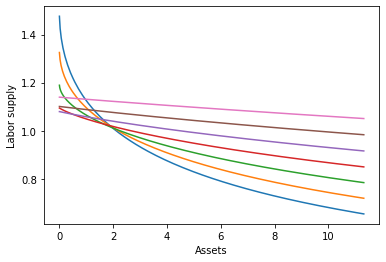

c(a;e)


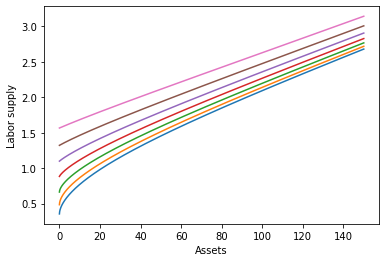

a(a_;e)


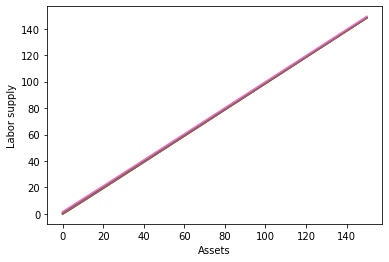

In [76]:
# Store steady state dictionary
ss = hank_ss()
ss['a_grid'][0:5].shape
# Plot labor supply, consumption, and savings as a function of assets for different shocks
print('n(a;e)')
plt.plot(ss['a_grid'][0:300], ss['n'].T[0:300])
plt.xlabel('Assets'), plt.ylabel('Labor supply')
plt.show()
print('c(a;e)')
plt.plot(ss['a_grid'], ss['c'].T)
plt.xlabel('Assets'), plt.ylabel('Labor supply')
plt.show()
print('a(a_;e)')
plt.plot(ss['a_grid'], ss['a'].T)
plt.xlabel('Assets'), plt.ylabel('Labor supply')
plt.show()

n(a;e = min)


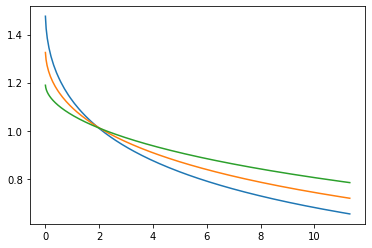

a(a;e = min)


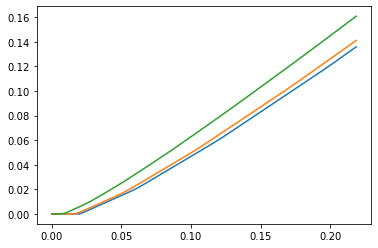

c(a;e = min)


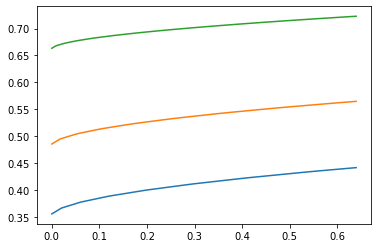

In [91]:
# The key thing to notice is that being at or close to the constraint affects people's consumption AND employment choices

print('n(a;e = min)')
plt.plot(ss['a_grid'][0:300], ss['n'].T[0:300,0:3])
plt.show()
# The closer people are at to the constraint, the more they'll want to work to get more assets, and relax their constraint
# Added value of savings AND employment effort when close to the constraint
# Employment becomes linear in assets after a while. Question: what if there was no constraint? 

print('a(a;e = min)')
plt.plot(ss['a_grid'][0:50], ss['a'].T[0:50,0:3])
plt.show()

# Savings policies minimally affected, you really have to zoom in to notice: those getting worse shock (right)
# ... see the constraint threshold shift to the right -- will be constrained even with higher assets.
# ... Those above below some threshold a_min will end up not being able to save

print('c(a;e = min)')
plt.plot(ss['a_grid'][0:100], ss['c'].T[0:100,0:3])
plt.show()

<a id="3-linear"></a>

## 3 Linearized dynamics using Jacobians
Recall that we reduced the to the following DAG:

![Directed Acyclical Graph](figures/hank1_dag.png) 

that can also be written as an implicit equation

$$
H(\pi, Y, w; r^*, Z) =
\begin{pmatrix}
\kappa \left(\frac{w_t}{Z_t} - \frac{1}{\mu} \right)  + \frac{1}{1+r_{t+1}} \frac{Y_{t+1}}{Y_t} \log(1+\pi_{t+1}) - \log(1+\pi_t)
\\
\mathcal{A}_t(\{r_s, w_s, \tau_s, d_s\})  - B
\\
\mathcal{L}_t(\{r_s, w_s, \tau_s, d_s\}) - L_t
\end{pmatrix}
= \begin{pmatrix} 0 \\ 0 \\ 0\end{pmatrix},
$$

to be solved for $U=(\pi, w, Y)$ given any $Z=(Z, r^*)$. The rest of the endogenous variables are be obtained as explicit functions of $(\pi, w, Y; Z, r^*)$ along the DAG, but it would be tedious to write them out.

Keep in mind that the implicit function theorem implies that the response of unknowns is

$$
dU = \underbrace{-H_U^{-1}H_Z}_{G_U} dZ \tag{1}
$$

For good practice, always start out from first principles: 

$$ H(U,Z) = 0 \implies H_U dU + H_Z dZ \implies dU = - H_U^{-1} H_Z dZ $$

Recall that we already solved for a steady state and stored is as `ss`. Furthermore, we will use a 300-period truncation horizon. 

### 3.1 Define simple blocks

Given $U = Y,w,\pi$S

*Firms* are responsible for production, and hence, demand labor, paying households labor income and profit dividends. 

$ L (Y;Z) = Y/Z $ 

$ d (Y,w,\pi;Z) = Y - w(Y/Z) - I_Y(\pi)Y =  Y(1 - \frac{w}{Z} - I_Y(\pi))$

*NKPC* is in a different block only fictitiously, since it's part of firms' dynamic investment decisions. The reason they break it up is that it is the part of the firm problem that containst $r$, and thus, is directly affected by MP, which we need to specify first. 

*Monetary Policy* can be specified as shocks to the cost of savings/investment (i.e. moving consumption forward when interest rates fall, and making investment cheaper, boosting output). We combine the Fisher equation with the Taylor rule.

Notice the difference in timing: a shock in the interest rate set today does not impact the returns on current savings, but rather, the returns on people that start saving now.

$ r_{t+1}(r^{*},\pi) = (1 + r^{*}_{t} + \phi * \pi_{t})/(1+\pi_{t+1}) - 1$

Given MP, the *NKPC* 

$ H_P(Y,w,\pi;Z,r^*) = \kappa \left(\frac{w_t}{Z_t} - 1/\mu\right) + \left(\frac{Y_{t+1}}{Y_{t}}\right)\frac{\log(1+\pi_{t+1})}{(1+r_{t+1}(r^{*},\pi) )}- \log(1 + \pi_t)$

Finally, to define the household block we need to get fiscal policy as a function of the equilibrium interest rate, which is the cost of raising debt to the government: higher interest rates will make governments have to raise taxes to sustain balanced debt levels, and thus, depress consumption via lowering lump sum transfers. 

$ \tau_t = r_t B $

Finally, we have three markets, the goods one clearing by Walras law (but we still check that it clears as a sanity check that the model is working). 

$H_A(A(w,r,d,\tau),B)$ = `A(w,monetary.r(pi,rstar,phi),fiscal.tau(monetary.r(pi,rstar,phi)) - B`
$H_L(L(w,r,d,\tau),L)$ = `LS(w,monetary.r(pi,rstar,phi),fiscal.tau(monetary.r(pi,rstar,phi)) - firm.L`
$H_C(L(w,r,d,\tau),Y)$ = `Y - C(w,monetary.r(pi,rstar,phi),fiscal.tau(monetary.r(pi,rstar,phi)) ...
                             - mu/(mu-1)/(2*kappa) * np.log(1+pi)**2 * Y`



In [92]:
# CAREFUL: DAG = exogenous, unknowns, + outputs of earlier blocks returned by block list. NOTE: endogenous inputs need to have the same name as the intermediate outputs. 

@simple
def firm(Y, w, Z, pi, mu, kappa):
    L = Y / Z
    Div = Y - w * L - mu/(mu-1)/(2*kappa) * np.log(1+pi)**2 * Y
    return L, Div

@simple
def monetary(pi, rstar, phi):
    r = (1 + rstar(-1) + phi * pi(-1)) / (1 + pi) - 1
    return r

@simple
def fiscal(r, B):
    Tax = r * B
    return Tax

# With two targets: recall block_list are "function names" while "targets" are function outputs

@simple
def mkt_clearing(A, NS, C, L, Y, B, pi, mu, kappa):
    asset_mkt = A - B
    labor_mkt = NS - L
    goods_mkt = Y - C - mu/(mu-1)/(2*kappa) * np.log(1+pi)**2 * Y
    return asset_mkt, labor_mkt, goods_mkt

@simple
def nkpc(pi, w, Z, Y, r, mu, kappa):
    nkpc_res = kappa * (w / Z - 1 / mu) + Y(+1) / Y * np.log(1 + pi(+1)) / (1 + r(+1)) - np.log(1 + pi)
    return nkpc_res

### 3.2 Cut to the chase
The surest way to obtain the general equilibrium Jacobians is to use the `get_G` convenience function. Notice the `save=True` option. This means that we're saving the HA Jacobians calculated along the way for later use.

Recall from KS

    `G = jac.get_G(block_list=[firm, mkt_clearing, household], 
               exogenous=['Z'],
               unknowns=['K'],
               targets=['asset_mkt'],
               T=T, ss=ss)`
               
Now we would have the following 

   `G = jac.get_G(block_list  =[firm, mkt_clearing, household, monetary, fiscal, nkpc], 
               exogenous      =['Z, rstar'],
               unknowns       =['Y', 'pi', 'w'],
               targets        =['asset_mkt','nkpc_res','labor_mkt'],
               T=T, ss=ss)`

In [93]:
# General settup
T = 300
exogenous = ['rstar', 'Z']
unknowns = ['pi', 'w', 'Y']
targets = ['nkpc_res', 'asset_mkt', 'labor_mkt']

# general equilibrium jacobians
block_list = [firm, monetary, fiscal, nkpc, mkt_clearing, household] 
G          = jac.get_G(block_list, exogenous, unknowns, targets, T, ss, save=True)

In [96]:
# Prints out Jacobians of all endogenous variables wrt rstar and Z
G


{'Tax': {'rstar': array([[ 1.22673877e+00,  1.63510326e+00,  1.85416134e+00, ...,
           1.24071993e-11,  1.34206850e-11,  0.00000000e+00],
         [ 4.19234425e+00, -1.44009657e+00, -1.38175354e+00, ...,
          -6.66828396e-12, -7.82939334e-12,  0.00000000e+00],
         [-5.66712610e-01,  4.52627200e+00, -1.06840931e+00, ...,
          -5.29649716e-12, -4.95669028e-12,  0.00000000e+00],
         ...,
         [-2.76099906e-09, -2.45256675e-09, -2.06938608e-09, ...,
          -1.05327153e+00, -1.11211495e+00,  0.00000000e+00],
         [-2.75799982e-09, -2.44947355e-09, -2.06636998e-09, ...,
           4.55644758e+00, -1.18163457e+00,  0.00000000e+00],
         [-2.62768442e-09, -2.33339041e-09, -1.96811528e-09, ...,
          -5.18008056e-01,  4.42056985e+00,  0.00000000e+00]]),
  'Z': array([[ 1.15708718e+00,  8.32048503e-01,  5.29846539e-01, ...,
           1.86855977e-11,  1.65371823e-11,  2.00092295e-11],
         [-1.86640226e+00, -1.94487741e-01, -2.85741905e-02, ...,
 

### 3.3 Break down `get_G`

Under the hood, the very powerful `jac.get_G` performs the following steps:
 1. (Topological sort) orders the blocks so that we move forward along the model's DAG

  For example, we need to `def monetary(pi, rstar, phi)` first before using returned `r` in  `Tax = fiscal(r, B)`.
  
 2. (Partial derivatives) computes the partial Jacobians $\mathcal{J}^{o,i}$ from all blocks (if their Jacobian is not supplied already), only with respect to the inputs that actually change: unknowns, exogenous shocks, outputs of earlier blocks
 
 $\mathcal{J}^{o,i}$ will be in `curlyJs` , a list of nested dictionaries with entries being all the necessary Jacobians for the corresponding block. Blocks are ordered according to the topological sort given by the DAG. 
 
  For example, computes the Jacobians of `monetary` $\mathcal{J}^{r,i}$ for `i = pi,rstar` but not for exogenous `phi` and the Jacobian of fiscal  $\mathcal{J}^{r,\tau}$ which only has one endogenous input and no shock (only parameter `B`. While `r` is endogenous itself, here it is treated as if it was exogenous. 
  
 3. (Chain rule) forward accumulates partial Jacobians $\mathcal{J}^{o,i}$ to form total Jacobians $\mathbf{J}^{o,i}$
 
 For example, a change  $\mathcal{J}^{r,rstar}$ in monetary will feed into a change  $\mathcal{J}^{r,rstar}$  $\mathcal{J}^{\tau,r}$ from fiscal. 
 
 4. (Exogenous vs endogenous var Jacobians) packs $\mathbf{J}^{o,i}$ to form $\mathbf{H_U}$ and $\mathbf{H_Z}$
 
 Separaters between endogenous variables (`U = pi,Y,w`) and exogenous shocks (Z) and calculates each Jacobian. 
 
 5. (Implicit Function Theorem) solves for the GE Jacobians for unknowns $\mathbf{G_U} = \mathbf{H_U}^{-1}\mathbf{H_Z}$
  
 6. forward accumulates GE Jacobians to obtain $\mathbf{G}$ for other endogenous variables
 
 Goes back to 1-2, and calculates Jacobians for all variables that are not in (`U = pi,Y,w`)
 
Let's take a closer look at each.

#### Step 1: Topological sort and partial Jacobians
By looking at the inputs and outputs of each block, we can order them so that we only move forward on the DAG (this is called a **topological sort**). *Knowing the DAG is a prerequisite* for all that follows, and also allows us to *avoid wasteful Jacobian calculations*: we only need Jacobians with respect to unknowns, exogenous, and outputs of earlier blocks.

DAG = exogenous, unknowns, + outputs of earlier blocks returned by block list. NOTE: endogenous inputs need to have the same name as the intermediate outputs. 

In [98]:
curlyJs, required = jac.curlyJ_sorted(block_list, unknowns+exogenous, ss, T)

The first output `curlyJs` is a list of nested dictionaries. Each entry in the list contains all the necessary Jacobians for the corresponding block. Blocks are ordered according to the topological sort.

For example, the first block is `monetary`, because it only takes an unknown $\pi$ and an exogenous $r^*$ as inputs. Let's take a look. 

In [105]:
# A Jacobian from a SimpleBlock is sparse. Here r wrt inputs in monetary block -- pi, rstar
print(curlyJs[0])

# A Jacobian from a HetAgent block is not sparse. Here A wrt inputs in asset_mkt block -- Tax, Div, w, r and so on. 
print(curlyJs[4])



curlyJs



{'r': {'pi': SimpleSparse({(0, 0): -1.005, (-1, 0): 1.500}), 'rstar': SimpleSparse({(-1, 0): 1.000})}}
{'A': {'Tax': array([[-8.73838655e-01,  3.95295672e-02,  3.62911361e-02, ...,
         4.65276320e-08,  4.43745875e-08,  4.23213519e-08],
       [-8.38664510e-01, -8.38794367e-01,  7.30512138e-02, ...,
         9.43167299e-08,  8.99522681e-08,  8.57899415e-08],
       [-8.06563561e-01, -8.06344401e-01, -8.07813416e-01, ...,
         1.43460015e-07,  1.36821735e-07,  1.30490541e-07],
       ...,
       [-1.38981120e-04, -1.39146249e-04, -1.39485118e-04, ...,
        -4.34563386e-01,  4.61822274e-01,  4.41355348e-01],
       [-1.34947852e-04, -1.35108177e-04, -1.35437198e-04, ...,
        -4.18544796e-01, -4.34563386e-01,  4.61822274e-01],
       [-1.31031637e-04, -1.31187298e-04, -1.31506759e-04, ...,
        -4.03670944e-01, -4.18544796e-01, -4.34563386e-01]]), 'Div': array([[ 8.73841525e-01, -3.95320664e-02, -3.62922793e-02, ...,
        -4.65282258e-08, -4.43751077e-08, -4.23218776e

[{'r': {'pi': SimpleSparse({(0, 0): -1.005, (-1, 0): 1.500}),
   'rstar': SimpleSparse({(-1, 0): 1.000})}},
 {'nkpc_res': {'w': SimpleSparse({(0, 0): 0.100}),
   'pi': SimpleSparse({(0, 0): -1.000, (1, 0): 0.995}),
   'Z': SimpleSparse({(0, 0): -0.083})}},
 {'Tax': {'r': SimpleSparse({(0, 0): 5.600})}},
 {'L': {'Y': SimpleSparse({(0, 0): 1.000}),
   'Z': SimpleSparse({(0, 0): -1.000})},
  'Div': {'w': SimpleSparse({(0, 0): -1.000}),
   'Y': SimpleSparse({(0, 0): 0.167}),
   'pi': SimpleSparse({(0, 0): 0.000}),
   'Z': SimpleSparse({(0, 0): 0.833})}},
 {'A': {'Tax': array([[-8.73838655e-01,  3.95295672e-02,  3.62911361e-02, ...,
            4.65276320e-08,  4.43745875e-08,  4.23213519e-08],
          [-8.38664510e-01, -8.38794367e-01,  7.30512138e-02, ...,
            9.43167299e-08,  8.99522681e-08,  8.57899415e-08],
          [-8.06563561e-01, -8.06344401e-01, -8.07813416e-01, ...,
            1.43460015e-07,  1.36821735e-07,  1.30490541e-07],
          ...,
          [-1.38981120e-04

Since this is a simple block, the Jacobians are represented as a instances of the `SimpleSparse` class. 

**Note that `jac.curlyJ_sorted` correctly determined that it is not necessary to differentiate with respect to the Taylor rule parameter $\phi$ (if we wanted to consider shocks to this parameter, we'd just have to include it among the exogenous inputs.)**

The second output `required` is a **set of extra variables (not unknowns and exogenous)** that we have to differentiate with respect to, because *they are outputs of some blocks and inputs of others.* 

In [16]:
print(required)

{'Tax', 'L', 'NS', 'Div', 'A', 'r', 'C'}


#### Step 2: Compose Jacobians along the DAG
We're interested in the Jacobians with respect to the inputs of $H$, i.e. the *unknowns* $(\pi, w, Y)$ and the *shocks* $(r^*, Z).$  

First, we apply the chain rule by using `jac.forward_accumulate`. This gives the $T \times T$ building blocks of the $H_U$ and $H_Z$ that *relate targets to unknowns and exogenous*. 

In [111]:
# d U(unknowns) -> d Target Hs
J_curlyH_U = jac.forward_accumulate(curlyJs, unknowns, targets, required)

# d U(exogenous) -> d Target Hs
J_curlyH_Z = jac.forward_accumulate(curlyJs, exogenous, targets, required)

# There at 3 targets at the upper level in both cases
print(J_curlyH_U.keys())
print(J_curlyH_Z.keys())
# Each of which is driven by either endogenous unknowns or exogenous shocks
print(J_curlyH_U['asset_mkt'].keys())
print(J_curlyH_Z['asset_mkt'].keys())
# For example, there are two endogenous unknowns in the NKPC, w hits only today, pi hits today and tomorrow
print(J_curlyH_U['nkpc_res'])
# while there is only one exogenous shock there, hitting in the current period
print(J_curlyH_Z['nkpc_res'])

dict_keys(['nkpc_res', 'asset_mkt', 'labor_mkt'])
dict_keys(['nkpc_res', 'asset_mkt', 'labor_mkt'])
dict_keys(['pi', 'w', 'Y'])
dict_keys(['rstar', 'Z'])
{'w': SimpleSparse({(0, 0): 0.100}), 'pi': SimpleSparse({(0, 0): -1.000, (1, 0): 0.995})}
{'Z': SimpleSparse({(0, 0): -0.083})}


Next, we just have to pack them into two (big) matrices. These capture (to first order) **the implicit relationship between unknowns $X=(\pi, w, Y)$ induced by the requirement that markets clear and the Phillips curve holds, i.e. that the targets of the DAG evaluate to zero.**

In [18]:
H_U = jac.pack_jacobians(J_curlyH_U, unknowns, targets, T)
H_Z = jac.pack_jacobians(J_curlyH_Z, exogenous, targets, T)
# Note H_U contains 3 unknowns and 3 targets, hence will always be symmetric. Each jacobian we are stacking is TxT
print(H_U.shape)
# H_Z need not be symmetric. In this case, we have 3 U and 2 Z
print(H_Z.shape)


(900, 900)
(900, 600)


#### Step 3: General equilibrium Jacobians
First we can get the response of unknowns directly by the implicit function theorem.
`-np.linalg.solve(H_U, H_Z)` = `- H_U^(-1) H_Z` in Python speak.

In [120]:
G_U = jac.unpack_jacobians(-np.linalg.solve(H_U, H_Z), exogenous, unknowns, T)

print(G_U.keys())
# Each endogenous variable changes with each shock
print(G_U['w'].keys())
# The Jacobian
G_U['w']['rstar'].shape

dict_keys(['pi', 'w', 'Y'])
dict_keys(['rstar', 'Z'])


(300, 300)

In [125]:
G_U

{'pi': {'rstar': array([[-2.17970642e-01, -2.90530075e-01, -3.29452974e-01, ...,
          -2.20454856e-12, -2.38462775e-12, -0.00000000e+00],
         [-7.52128006e-02, -1.77746279e-01, -2.46206725e-01, ...,
          -2.10553019e-12, -2.16799569e-12, -0.00000000e+00],
         [-1.15627071e-02, -7.45097270e-02, -1.77634539e-01, ...,
          -2.20148480e-12, -2.35509480e-12, -0.00000000e+00],
         ...,
         [-6.62995406e-10, -5.88769976e-10, -4.96629253e-10, ...,
          -1.61992204e-01, -2.69641812e-01, -0.00000000e+00],
         [-4.99495663e-10, -4.43531316e-10, -3.74078847e-10, ...,
          -5.63578700e-02, -1.92494074e-01, -0.00000000e+00],
         [-2.78621028e-10, -2.47383199e-10, -2.08625985e-10, ...,
           7.92500868e-03, -7.77398860e-02,  0.00000000e+00]]),
  'Z': array([[-2.05594736e-01, -1.47840885e-01, -9.41447297e-02, ...,
          -3.32011331e-12, -2.93837639e-12, -3.55530019e-12],
         [ 2.47701624e-02, -1.86100870e-01, -1.35437374e-01, ...,
  

In [124]:
curlyJs

[{'r': {'pi': SimpleSparse({(0, 0): -1.005, (-1, 0): 1.500}),
   'rstar': SimpleSparse({(-1, 0): 1.000})}},
 {'nkpc_res': {'w': SimpleSparse({(0, 0): 0.100}),
   'pi': SimpleSparse({(0, 0): -1.000, (1, 0): 0.995}),
   'Z': SimpleSparse({(0, 0): -0.083})}},
 {'Tax': {'r': SimpleSparse({(0, 0): 5.600})}},
 {'L': {'Y': SimpleSparse({(0, 0): 1.000}),
   'Z': SimpleSparse({(0, 0): -1.000})},
  'Div': {'w': SimpleSparse({(0, 0): -1.000}),
   'Y': SimpleSparse({(0, 0): 0.167}),
   'pi': SimpleSparse({(0, 0): 0.000}),
   'Z': SimpleSparse({(0, 0): 0.833})}},
 {'A': {'Tax': array([[-8.73838655e-01,  3.95295672e-02,  3.62911361e-02, ...,
            4.65276320e-08,  4.43745875e-08,  4.23213519e-08],
          [-8.38664510e-01, -8.38794367e-01,  7.30512138e-02, ...,
            9.43167299e-08,  8.99522681e-08,  8.57899415e-08],
          [-8.06563561e-01, -8.06344401e-01, -8.07813416e-01, ...,
            1.43460015e-07,  1.36821735e-07,  1.30490541e-07],
          ...,
          [-1.38981120e-04

And the rest can be obtained by forward accumulation that accounts for the direct and indirect effects alike via the Chain Rule. curlyJs contains all the direct effects on all variables (exogenous, endogenous, interm outputs, targets). G_U has all indirect effects of exogenous on endogenous. 

In [127]:
# Combine the two dictionaries
curlyJs = [G_U] + curlyJs
curlyJs

[{'pi': {'rstar': array([[-2.17970642e-01, -2.90530075e-01, -3.29452974e-01, ...,
           -2.20454856e-12, -2.38462775e-12, -0.00000000e+00],
          [-7.52128006e-02, -1.77746279e-01, -2.46206725e-01, ...,
           -2.10553019e-12, -2.16799569e-12, -0.00000000e+00],
          [-1.15627071e-02, -7.45097270e-02, -1.77634539e-01, ...,
           -2.20148480e-12, -2.35509480e-12, -0.00000000e+00],
          ...,
          [-6.62995406e-10, -5.88769976e-10, -4.96629253e-10, ...,
           -1.61992204e-01, -2.69641812e-01, -0.00000000e+00],
          [-4.99495663e-10, -4.43531316e-10, -3.74078847e-10, ...,
           -5.63578700e-02, -1.92494074e-01, -0.00000000e+00],
          [-2.78621028e-10, -2.47383199e-10, -2.08625985e-10, ...,
            7.92500868e-03, -7.77398860e-02,  0.00000000e+00]]),
   'Z': array([[-2.05594736e-01, -1.47840885e-01, -9.41447297e-02, ...,
           -3.32011331e-12, -2.93837639e-12, -3.55530019e-12],
          [ 2.47701624e-02, -1.86100870e-01, -1.35437

In [132]:
# While targets is an array, we want to set it into a dictionary
print(targets)
print(set(targets))

['nkpc_res', 'asset_mkt', 'labor_mkt']
{'asset_mkt', 'labor_mkt', 'nkpc_res'}


In [136]:
#We are interested changes in all variables that are not targets (endogenous objects and outputs)

outputs = set().union(*(curlyJ.keys() for curlyJ in curlyJs)) - set(targets) 

print(outputs)

{'Tax', 'L', 'w', 'N', 'NS', 'goods_mkt', 'Y', 'pi', 'Div', 'A', 'r', 'C'}


In [ ]:
# Use chain rule to forward accumulate Jacobians: dr = (dr/drstar + dr/dpi(dpi/drstar)) drstar
G2 = jac.forward_accumulate(curlyJs, exogenous, outputs, required | set(unknowns))

In [139]:
# Should contain Jacobians of all outputs and endogenous objects wrt all shocks Z and rstar
G2

{'Tax': {'rstar': array([[ 1.22673877e+00,  1.63510326e+00,  1.85416134e+00, ...,
           1.24071993e-11,  1.34206850e-11,  0.00000000e+00],
         [ 4.19234425e+00, -1.44009657e+00, -1.38175354e+00, ...,
          -6.66828396e-12, -7.82939334e-12,  0.00000000e+00],
         [-5.66712610e-01,  4.52627200e+00, -1.06840931e+00, ...,
          -5.29649716e-12, -4.95669028e-12,  0.00000000e+00],
         ...,
         [-2.76099906e-09, -2.45256675e-09, -2.06938608e-09, ...,
          -1.05327153e+00, -1.11211495e+00,  0.00000000e+00],
         [-2.75799982e-09, -2.44947355e-09, -2.06636998e-09, ...,
           4.55644758e+00, -1.18163457e+00,  0.00000000e+00],
         [-2.62768442e-09, -2.33339041e-09, -1.96811528e-09, ...,
          -5.18008056e-01,  4.42056985e+00,  0.00000000e+00]]),
  'Z': array([[ 1.15708718e+00,  8.32048503e-01,  5.29846539e-01, ...,
           1.86855977e-11,  1.65371823e-11,  2.00092295e-11],
         [-1.86640226e+00, -1.94487741e-01, -2.85741905e-02, ...,
 

### 3.4 Results
First let's check that we have correctly reconstructed the steps of `jac.get_G`.

In [141]:
for out in G:
    for inp in G[out]:
        assert np.allclose(G[out][inp], G2[out][inp])

Now let's consider 25 basis point monetary policy shocks with different persistences and plot the response of inflation.

As before, we are shocking from the steady state calibrated to start from $Y=1$ and assuming the initial shock size at $t=1$ is common across shocks to be $-\Delta = -0.0025$ (0.25% decline in interest rates, or a monetary expansion). 

$ dr^{*}(t) = -(\Delta) \rho^{t-1}$

In [152]:
# We get a time vector 300x1 
periods = np.arange(T)
periods[0:5]

# and a persistence vector 5 x 1
rhos = np.array([0,0.2, 0.4, 0.6, 0.8, 0.9])
rhos

# rhos ** (periods[:]) Wouldnt work because they have different dimension, we need to repmat one of them

array([0. , 0.2, 0.4, 0.6, 0.8, 0.9])

Shocks


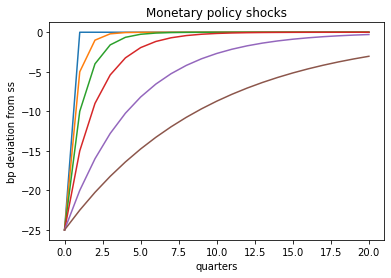

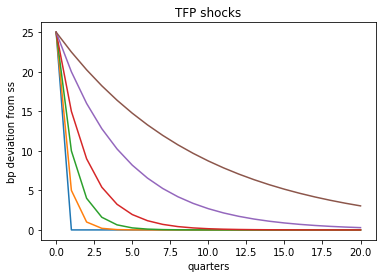

Monetary Policy


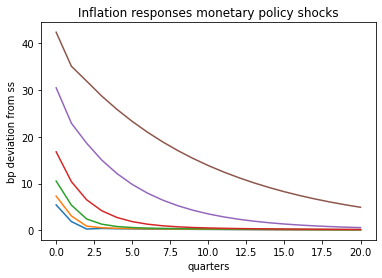

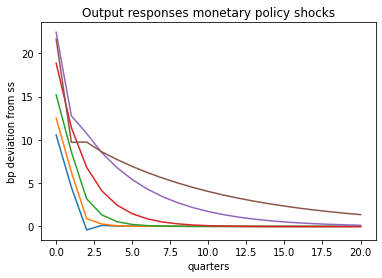

TFP


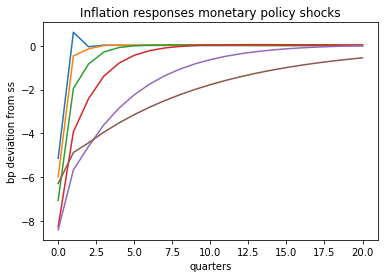

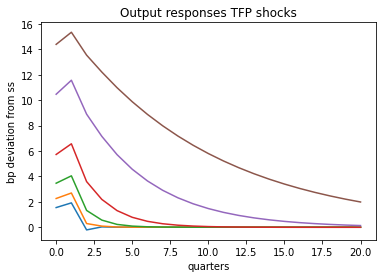

In [162]:
print('Shocks')
drstar = -0.0025 * rhos ** (periods[:, np.newaxis])
plt.plot(10000 * drstar[:21])
plt.title(r'Monetary policy shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()

dZ = 0.0025 * ss['Z'] * rhos ** (periods[:, np.newaxis])
plt.plot(10000 * dZ[:21])
plt.title(r'TFP shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()


print('Monetary Policy')
# Recall the IRF = dpi = G[pi,rstar] drstar where G[pi,rstar] TxT and dstar T,

dpi = G['pi']['rstar'] @ drstar

plt.plot(10000 * dpi[:21])
plt.title(r'Inflation responses monetary policy shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()

dY = G['Y']['rstar'] @ drstar

plt.plot(10000 * dY[:21])
plt.title(r'Output responses monetary policy shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()

print('TFP') 

dpi = G['pi']['Z'] @ dZ

plt.plot(10000 * dpi[:21])
plt.title(r'Inflation responses monetary policy shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()

dY = G['Y']['Z'] @ dZ

plt.plot(10000 * dY[:21])
plt.title(r'Output responses TFP shocks')
plt.xlabel('quarters')
plt.ylabel('bp deviation from ss')
plt.show()

<a id="4-nonlinear"></a>

## 4. Nonlinear dynamics
Conceptually there's nothing new in this section compared to the Krusell-Smith notebook. We're going to implement a quasi-Newton algorithm to solve for the unknown sequences $U=(\pi, w, Y)$ given some sequences of shocks $(r^*, Z).$ We initialize the algorithm by the naive guess that the variables in $U$ stay constant at their steady-state level. Then we evaluate the DAG and update the guess using the inverse Jacobian $H_U^{-1}.$ The algorithm converges in a few steps, despite the presence of substantial nonlinearities.

Recall for quasi Newton we needed to specify a given path of the shock to $r^*$, here monetary policy, and solve for unknowns

$$U_{1} = U_{0} - H_U(U_{ss},r^{*}_{ss})^{-1}H(U_{0},r^{*})$$

Note the shock changes r via the Fisher equation, and thus affects both asset and labor market clearing directly (via households consumption and labor supply by moving consumption to the present, both of which stymulate the economy by allowing output to expand (with more labor available and consumer demand) and also decreases the price of investment by firms, reducing the price of investment or adjusting prices, having firms being able to adjust prices faster in response to the shock, increasing inflation. 


### 4.1 A typical monetary policy shock
Note that the linearized solution ignores price adjustment costs. For a monetary policy shock of typical size and persistence, this does not really matter.   
Note that in the steady state with zero inflation, interest rates are part of our steady state calibration

$$ r = i = r^*$$ 
$$ r_t = r + \sigma_r \rho^{t-1}$$

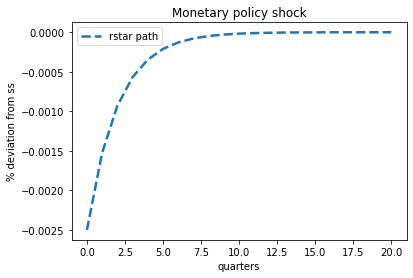

In [170]:
# We need to specify the shape of a MP shock, setting up its persistence and size of the impulse. Note shocks will be negative only

rho_r, sig_r = 0.61, -0.01/4

# Note we are feeding a quarterly 1% shock, or 0.0025

drstar = sig_r * rho_r ** (np.arange(T))

rstar = ss['r'] + drstar

plt.plot(rstar[:21] - ss['r'], label='rstar path', linestyle='--', linewidth=2.5)
plt.title(r'Monetary policy shock')
plt.xlabel('quarters')
plt.ylabel('% deviation from ss')
plt.legend()
plt.show()


Recall our key object `H_U` are the Jacobians of the equilibrium targets wrt unknowns. 

We can get this directly 

`H_U = jac.get_H_U(block_list, unknowns, targets, T, ss, use_saved=True)`

In [182]:
H_U = jac.get_H_U(block_list, unknowns, targets, T, ss, use_saved=True)
H_U_factored = utils.factor(H_U)

In [185]:
# Use quasi-Newton to clear all the targets

td_nonlin = nonlinear.td_solve(ss, block_list, unknowns, targets, H_U_factored=H_U_factored,rstar=rstar)

# To get the non-linear transitional dynamics given a pre-specified path of exogenous rstar
td_nonlin

On iteration 0
   max error for nkpc_res is 0.00E+00
   max error for asset_mkt is 1.46E-02
   max error for labor_mkt is 2.73E-03
On iteration 1
   max error for nkpc_res is 1.16E-06
   max error for asset_mkt is 1.33E-04
   max error for labor_mkt is 6.89E-06
On iteration 2
   max error for nkpc_res is 4.81E-08
   max error for asset_mkt is 2.21E-06
   max error for labor_mkt is 1.42E-07
On iteration 3
   max error for nkpc_res is 1.26E-09
   max error for asset_mkt is 3.46E-08
   max error for labor_mkt is 8.41E-10
On iteration 4
   max error for nkpc_res is 2.10E-11
   max error for asset_mkt is 5.01E-10
   max error for labor_mkt is 1.26E-11


{'rstar': array([0.0025    , 0.003475  , 0.00406975, 0.00443255, 0.00465385,
        0.00478885, 0.0048712 , 0.00492143, 0.00495207, 0.00497076,
        0.00498217, 0.00498912, 0.00499336, 0.00499595, 0.00499753,
        0.00499849, 0.00499908, 0.00499944, 0.00499966, 0.00499979,
        0.00499987, 0.00499992, 0.00499995, 0.00499997, 0.00499998,
        0.00499999, 0.00499999, 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005     , 0.005     , 0.005     ,
        0.005     , 0.005     , 0.005  

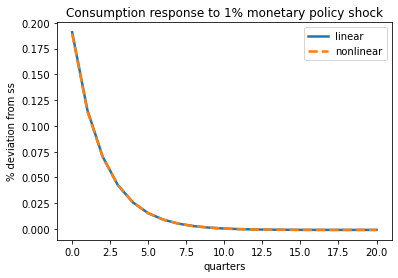

In [186]:
# Recall linear % deviations from steady state: dC/C(ss) = G(C,rstar) drstar /C(ss)

dC_lin = 100 * G['C']['rstar'] @ drstar / ss['C']

# While non-linar % deviations from steady state: dC = (C(r)/C(ss)) - 1

dC_nonlin = 100 * (td_nonlin['C']/ss['C'] - 1) 

plt.plot(dC_lin[:21], label='linear', linestyle='-', linewidth=2.5)
plt.plot(dC_nonlin[:21], label='nonlinear', linestyle='--', linewidth=2.5)
plt.title(r'Consumption response to 1% monetary policy shock')
plt.xlabel('quarters')
plt.ylabel('% deviation from ss')
plt.legend()
plt.show()

### 4.2 A very large monetary policy shock
However, the nonlinearities may become substantial for very large or persistent monetary policy shocks. Reassuringly, the Jacobian still works well as an updating rule. The quasi-Newton method for a 10% monetary policy shock (extremely large!) still converges below in just 9 iterations, despite nonlinearities evident in the results.

On iteration 0
   max error for nkpc_res is 0.00E+00
   max error for asset_mkt is 1.41E-01
   max error for labor_mkt is 2.68E-02
On iteration 1
   max error for nkpc_res is 9.66E-05
   max error for asset_mkt is 1.30E-02
   max error for labor_mkt is 5.55E-04
On iteration 2
   max error for nkpc_res is 2.62E-05
   max error for asset_mkt is 2.19E-03
   max error for labor_mkt is 7.31E-04
On iteration 3
   max error for nkpc_res is 3.84E-06
   max error for asset_mkt is 3.80E-04
   max error for labor_mkt is 9.03E-05
On iteration 4
   max error for nkpc_res is 1.50E-06
   max error for asset_mkt is 6.39E-05
   max error for labor_mkt is 1.83E-05
On iteration 5
   max error for nkpc_res is 1.26E-07
   max error for asset_mkt is 1.05E-05
   max error for labor_mkt is 2.52E-06
On iteration 6
   max error for nkpc_res is 3.47E-08
   max error for asset_mkt is 1.72E-06
   max error for labor_mkt is 4.66E-07
On iteration 7
   max error for nkpc_res is 3.43E-09
   max error for asset_mkt is 

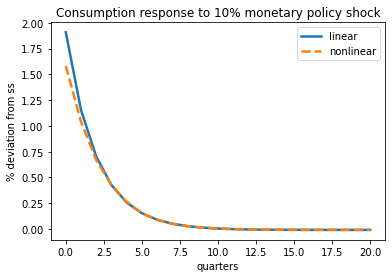

In [187]:
rho_r, sig_r = 0.61, -0.10/4
drstar = sig_r * rho_r ** (np.arange(T))
rstar = ss['r'] + drstar

td_nonlin = nonlinear.td_solve(ss, block_list, unknowns, targets, H_U_factored=H_U_factored, rstar=rstar)

dC_lin = 100 * G['C']['rstar'] @ drstar / ss['C']
dC_nonlin = 100 * (td_nonlin['C']/ss['C'] - 1) 

plt.plot(dC_lin[:21], label='linear', linestyle='-', linewidth=2.5)
plt.plot(dC_nonlin[:21], label='nonlinear', linestyle='--', linewidth=2.5)
plt.title(r'Consumption response to 10% monetary policy shock')
plt.xlabel('quarters')
plt.ylabel('% deviation from ss')
plt.legend()
plt.show()

<a id="5-determinacy"></a>

## 5. Local determinacy
Local determinacy boils down to the invertibility of the matrix $H_U$. The steady state is a locally-determinate equilibrium if and only if $H_U$ is invertible. 

**Numerical approach.** In practice, $H_U$ is obtained numerically for a finite horizon, and thus we can never expect it to be exactly singular, even if equilibrium is indeterminate. Still, near-singularity of $H_U$, especially when it becomes more drastic as the truncation horizon $T$ is increased, is a likely indication of indeterminacy.

In practice, we have found that indeterminacy is best detected by looking at the last few singular values: if the smallest is discontinuously smaller than the second and third smallest, then indeterminacy is likely.

**Our contribution: winding number criterion.** A better solution is to use the winding number criterion introduced in our paper, which rapidly gives an exact answer. This criterion exploits the "asymptotic time invariant" structure of the Jacobians in SHADE models: within each Jacobian, each diagonal eventually converges to some constant, and these constants are close to zero far enough away from the main diagonal.

Given knowledge of the asymptotic structure of $H_U$, which is encoded in an array $A$, the criterion calculates the "winding number" of the curve

$$
\det A(\lambda) = \det\sum_{j=-\infty}^\infty A_j e^{ij\lambda} \tag{1}
$$

as $\lambda$ varies from $0$ to $2\pi$. Here, $A_j$ is the $n_u\times n_u$ matrix representing the asymptotic value on the $j$th diagonal above the main diagonal for all pairs of targets and unknowns. The "winding number" is the number of times the curve (1) wraps counterclockwise around the origin in the complex plane.

A winding number of 0 indicates that the model has a unique solution around the steady state, while a winding number of -1 or less indicates indeterminacy.

**Example in our HANK model.** As it is well-known, determinacy in the New Keynesian models requires that the interest rate rule is sufficiently responsive to inflation. Therefore, we're going to illustrate the issue by varying the parameter $\phi$ and tracing its effect on $H_U.$

### 5.1 Stable case
Let's start with the the baseline calibration with $\phi=1.5$. Both approaches show the model is determinate, as expected.

In [26]:
# smallest singular values
_, s, _ = np.linalg.svd(H_U)
print(f'Smallest singular values: {s[-3]:.4f}, {s[-2]:.4f}, {s[-1]:.4f}')

# winding number test
# first, use get_H_U with asymptotic=True to get array A representing asymptotic H_U
A = jac.get_H_U(block_list, unknowns, targets, T, ss, asymptotic=True, save=True, use_saved=True)

# then apply winding number criterion
wn = det.winding_criterion(A)
print(f'Winding number: {wn}')

Smallest singular values: 0.0720, 0.0715, 0.0715
Winding number: 0


### 5.2 Unstable case
Let's see what happens with $\phi=0.75$. First of all, we'll have to recompute the Jacobian. It's important to realize that $\phi$ does not affect the steady state, and affects dynamics only through the monetary block. Thus, recomputing the Jacobians of the household block would be wasteful. We can avoid this by setting ``use_saved=True``. 

In [27]:
ss2 = {**ss, 'phi': 0.75}
H_U2 = jac.get_H_U(block_list, unknowns, targets, T, ss2, use_saved=True)

This time both tests reveal clear indeterminacy: the smallest singular value is discontinuously smaller than the others, and the winding number is -1.

In [28]:
# smallest singular values
_, s2, _ = np.linalg.svd(H_U2)
print(f'Smallest singular values: {s2[-3]:.4f}, {s2[-2]:.4f}, {s2[-1]:.4f}')

# winding number
A2 = jac.get_H_U(block_list, unknowns, targets, T, ss2, asymptotic=True, use_saved=True)
wn2 = det.winding_criterion(A2)
print(f'Winding number: {wn2}')

Smallest singular values: 0.0967, 0.0960, 0.0000
Winding number: -1


Not surprisingly, if we tried to use this Jacobian to compute impulse responses, we'd fail. (We'll wrap in a try/except block to avoid a giant error message.)

In [29]:
try:
    td_nonlin = nonlinear.td_solve(ss2, block_list, unknowns, targets, H_U=H_U2,rstar=rstar)
except ValueError as e:
    print(e)

On iteration 0
   max error for nkpc_res is 0.00E+00
   max error for asset_mkt is 1.41E-01
   max error for labor_mkt is 2.68E-02
Cannot solve constrained household's problem: No convergence after 30 iterations!


<ipython-input-12-c838c562b067>:26: RuntimeWarning: invalid value encountered in log
  nkpc_res = kappa * (w / Z - 1 / mu) + Y(+1) / Y * np.log(1 + pi(+1)) / (1 + r(+1)) - np.log(1 + pi)
<ipython-input-12-c838c562b067>:4: RuntimeWarning: invalid value encountered in log
  Div = Y - w * L - mu/(mu-1)/(2*kappa) * np.log(1+pi)**2 * Y


In fact, it fails after the first iteration: since the Jacobian is nearly singular, using its inverse in Newton's method leads to a very large step to the next guess, which then is outside the admissible domain and leads to an error within the household routine.

### 5.3 Why use the winding number criterion?

It's very fast and precise. We can use bisection, for instance, to get the exact threshold at which the model becomes determinate. It turns out that this is at approximately $\phi=1.005$.

In [30]:
phi_low = 0.8
phi_high = 1.2
while phi_high - phi_low > 1E-6:
    phi_mid = (phi_low + phi_high)/2
    ss_cur = {**ss, 'phi': phi_mid}
    A_cur = jac.get_H_U(block_list, unknowns, targets, T, ss_cur,
                                        asymptotic=True, use_saved=True)
    wn_cur = det.winding_criterion(A_cur)
    if wn_cur == 0:
        phi_high = phi_mid
    else:
        phi_low = phi_mid
phi_threshold = (phi_low + phi_high)/2
print(f'Threshold for determinacy: phi={phi_threshold:.3f}')

Threshold for determinacy: phi=1.005


We can compare to the results from looking at singular values. Specifically, we'll look at the ratio of the smallest to the second-smallest singular value for a range of $\phi$ around the determinacy threshold we've identified.

This takes several seconds, because the singular value decomposition is costly and we need to redo it for every $\phi$.

In [31]:
# non-uniform grid of phis to get extra precision near
# where we know from winding number test the threshold lies
phis = np.unique(np.concatenate((np.linspace(0.99, 1.00, 5),
                                 np.linspace(1.00, 1.01, 10),
                                 np.linspace(1.01, 1.02, 5))))

sv_ratio = np.empty_like(phis)
for it, phi in enumerate(phis):
    ss_cur = {**ss, 'phi': phi}
    H_U_cur = jac.get_H_U(block_list, unknowns, targets, T, ss_cur, use_saved=True)

    _, s, _ = np.linalg.svd(H_U_cur)
    sv_ratio[it] = s[-1] / s[-2]

Let's plot this ratio against the winding number plus 1, which jumps up at the determinacy threshold we've already calculated.

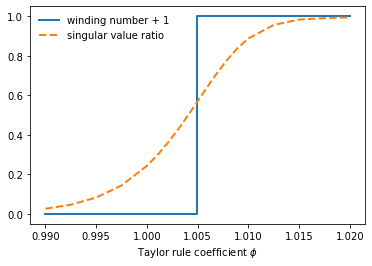

In [32]:
# winding number plus 1 jumps up at phi_threshold
phis_wn = [phis[0], phi_threshold, phi_threshold, phis[-1]]
wns = [0, 0, 1, 1]

plt.plot(phis_wn, wns, linewidth=2, label=r'winding number + 1')
plt.plot(phis, sv_ratio, linewidth=2, label=r'singular value ratio', linestyle='--')
plt.legend(framealpha=0)
plt.xlabel(r'Taylor rule coefficient $\phi$');

We see that the two approaches give consistent answers, but the winding number approach is far more precise and immediate.

### 5.4 Visualizing the winding number criterion
To see how this works, we can also directly plot the curve $\det A(\lambda)$ for which we're taking the winding number. The function `det.detA_path`, which is called by `det.winding_criterion` under the hood, provides this.

**Indeterminate case.** First let's do so for an indeterminate case $\phi=1.001$.

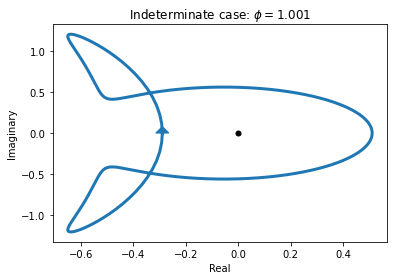

In [33]:
phi = 1.001
ss_cur = {**ss, 'phi': phi}
A_cur = jac.get_H_U(block_list, unknowns, targets, T, ss_cur,
                    asymptotic=True, use_saved=True)

det_Alambda = det.detA_path(A_cur)
x, y = det_Alambda.real, det_Alambda.imag

# plot curve
plt.plot(x, y, label=r'$\det A(\lambda)$', linewidth=3);

# dot for origin
plt.plot(0, 0, marker='o', markersize=5, color="black")

# arrow to show orientation (using rate of change around lambda=0)
plt.arrow(x[0], y[0], 0.001*(x[1]-x[-2]), 0.001*(y[1]-y[-2]), color='C0',
          width=0.0001, head_width=0.05, head_length=0.08)
plt.title(r'Indeterminate case: $\phi=1.001$')
plt.xlabel(r'Real')
plt.ylabel(r'Imaginary');

We clearly see the winding number of -1 here, corresponding to a single clockwise trajectory around the origin.

**Determinate case.** Now let's try the same for $\phi=1.007$.

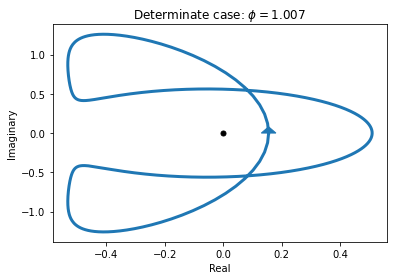

In [34]:
phi = 1.007
ss_cur = {**ss, 'phi': phi}
A_cur = jac.get_H_U(block_list, unknowns, targets, T, ss_cur,
                    asymptotic=True, use_saved=True)

det_Alambda = det.detA_path(A_cur)
x, y = det_Alambda.real, det_Alambda.imag

# plot curve
plt.plot(x, y, label=r'$\det A(\lambda)$', linewidth=3);

# dot for origin
plt.plot(0, 0, marker='o', markersize=5, color="black")

# arrow to show orientation (using rate of change around lambda=0)
plt.arrow(x[0], y[0], 0.001*(x[1]-x[-2]), 0.001*(y[1]-y[-2]), color='C0',
          width=0.0001, head_width=0.05, head_length=0.08)
plt.title(r'Determinate case: $\phi=1.007$')
plt.xlabel(r'Real')
plt.ylabel(r'Imaginary');

Here the winding number is zero: the curve has shifted such that it no longer wraps around the origin at all.